# 07 — Long-Tail Loss Comparison and Final Loss Freeze

**Project:** Pedi-CGAM Lite  
**Backbone:** Frozen ResNet50 @ 320×320  
**Stage:** Long-tail loss comparison  
**Losses:** BCE, Weighted BCE, Focal Loss, Asymmetric Loss (ASL)

This notebook performs **no training**.

It loads the saved outputs from the four controlled loss experiments, verifies that they used the same frozen Stage 02 split and ResNet50-320 protocol, compares overall and Head/Middle/Tail performance, and freezes the loss function for the later finding-supervision / box-guidance / CGAM stages.

## Required Kaggle inputs

Attach the saved outputs of:

- `05A_Round2_ResNet50_320` — plain BCE reference
- `06B_ResNet50_320_WeightedBCE`
- `06C_ResNet50_320_FocalLoss`
- `06D_ResNet50_320_AsymmetricLoss`

You may attach either the saved notebook outputs directly or their generated ZIP files.

You do **not** need the VinDr-PCXR dataset, Stage 02, GPU, or Internet for this comparison notebook.

## Frozen selection rule

The final loss is selected primarily by:

**14-pathology validation Macro-AUPRC**

Secondary evidence:

- Tail Macro-AUPRC
- Head / Middle / Tail balance
- 14-pathology Macro-AUROC
- fixed-threshold F1 / sensitivity
- runtime and GPU memory

The ultra-rare tail validation labels contain very few positive cases, so Tail Macro-AUPRC is important evidence but is **not allowed to override a clear primary-metric winner by itself**.

## Expected output ZIP

`/kaggle/working/PediCGAM_Stage07_LongTail_Loss_Comparison_All_Outputs.zip`


In [1]:
# ============================================================
# 1. Imports / constants
# ============================================================
from pathlib import Path
import json
import zipfile
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KAGGLE_INPUT = Path("/kaggle/input")

OUTPUT_DIR = Path(
    "/kaggle/working/PediCGAM/stage07_longtail_loss_comparison"
)
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXPECTED_EXPERIMENTS = {
    "R2A_ResNet50_320": "BCE",
    "L01_ResNet50_320_WeightedBCE": "Weighted BCE",
    "L02_ResNet50_320_FocalLoss": "Focal Loss",
    "L03_ResNet50_320_ASL": "Asymmetric Loss",
}

EXPECTED_SPLIT_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

EXPECTED_COMMON_PROTOCOL = {
    "backbone": "ResNet50",
    "image_size": 320,
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "batch_size": 8,
    "max_epochs": 25,
    "early_stopping_patience": 5,
    "seed": 42,
    "train_images": 5408,
    "validation_images": 1159,
    "calibration_used": False,
    "official_test_used": False,
}

print("Expected experiments:")
for exp_id, loss_name in EXPECTED_EXPERIMENTS.items():
    print(f"- {exp_id}: {loss_name}")


Expected experiments:
- R2A_ResNet50_320: BCE
- L01_ResNet50_320_WeightedBCE: Weighted BCE
- L02_ResNet50_320_FocalLoss: Focal Loss
- L03_ResNet50_320_ASL: Asymmetric Loss


In [2]:
# ============================================================
# 2. Extract attached experiment ZIPs if present
# ============================================================
EXTRACT_ROOT = Path("/kaggle/working/stage07_extracted_inputs")
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

zip_candidates = list(KAGGLE_INPUT.rglob("*.zip"))

print("ZIP files found:", len(zip_candidates))

for zp in zip_candidates:
    lower = zp.name.lower()

    relevant = any(
        token in lower
        for token in [
            "resnet50_320",
            "weightedbce",
            "focalloss",
            "asl",
            "r2a",
            "l01",
            "l02",
            "l03",
        ]
    )

    if not relevant:
        continue

    target = EXTRACT_ROOT / zp.stem

    if target.exists():
        continue

    target.mkdir(parents=True, exist_ok=True)

    try:
        with zipfile.ZipFile(zp, "r") as zf:
            zf.extractall(target)
        print("✅ Extracted:", zp)
    except zipfile.BadZipFile:
        print("⚠️ Skipped invalid ZIP:", zp)


ZIP files found: 4
✅ Extracted: /kaggle/input/notebooks/kalloldaskushol/06b-resnet50-320-weightedbce/L01_ResNet50_320_WeightedBCE_All_Outputs.zip
✅ Extracted: /kaggle/input/notebooks/kalloldaskushol/05a-round2-resnet50-320/R2A_ResNet50_320_All_Outputs.zip
✅ Extracted: /kaggle/input/notebooks/kalloldaskushol/06d-resnet50-320-asymmetricloss/L03_ResNet50_320_ASL_All_Outputs.zip
✅ Extracted: /kaggle/input/notebooks/kalloldaskushol/06c-resnet50-320-focalloss-fixed/L02_ResNet50_320_FocalLoss_All_Outputs.zip


In [3]:
# ============================================================
# 3. Discover the four experiment output directories
# ============================================================
SEARCH_ROOTS = [KAGGLE_INPUT, EXTRACT_ROOT]

discovered = {}

for root in SEARCH_ROOTS:
    for config_path in root.rglob("config.json"):
        try:
            cfg = json.loads(config_path.read_text())
        except Exception:
            continue

        exp_id = cfg.get("experiment_id")

        if exp_id in EXPECTED_EXPERIMENTS:
            current = discovered.get(exp_id)

            # Prefer the candidate that contains the most standard outputs.
            candidate_root = config_path.parent
            score = sum(
                (candidate_root / rel).exists()
                for rel in [
                    "tables/summary_metrics.csv",
                    "tables/per_class_metrics.csv",
                    "tables/head_middle_tail_metrics.csv",
                    "validation_predictions.csv",
                    "training_history.csv",
                    "environment_info.json",
                    "best_model.pth",
                ]
            )

            if current is None or score > current["score"]:
                discovered[exp_id] = {
                    "root": candidate_root,
                    "config_path": config_path,
                    "config": cfg,
                    "score": score,
                }

print("Discovery results:")
for exp_id in EXPECTED_EXPERIMENTS:
    if exp_id in discovered:
        print(
            "✅",
            exp_id,
            "->",
            discovered[exp_id]["root"],
            "| completeness score:",
            discovered[exp_id]["score"],
        )
    else:
        print("❌", exp_id)

missing = [
    exp_id
    for exp_id in EXPECTED_EXPERIMENTS
    if exp_id not in discovered
]

if missing:
    raise FileNotFoundError(
        "Missing long-tail loss outputs: "
        + ", ".join(missing)
        + ". Attach the saved outputs or ZIPs for 05A, 06B, 06C, and 06D."
    )

print("\n✅ All four loss experiments discovered.")


Discovery results:
✅ R2A_ResNet50_320 -> /kaggle/input/notebooks/kalloldaskushol/05a-round2-resnet50-320/PediCGAM/R2A_ResNet50_320 | completeness score: 6
✅ L01_ResNet50_320_WeightedBCE -> /kaggle/input/notebooks/kalloldaskushol/06b-resnet50-320-weightedbce/PediCGAM/L01_ResNet50_320_WeightedBCE | completeness score: 6
✅ L02_ResNet50_320_FocalLoss -> /kaggle/input/notebooks/kalloldaskushol/06c-resnet50-320-focalloss-fixed/PediCGAM/L02_ResNet50_320_FocalLoss | completeness score: 6
✅ L03_ResNet50_320_ASL -> /kaggle/input/notebooks/kalloldaskushol/06d-resnet50-320-asymmetricloss/PediCGAM/L03_ResNet50_320_ASL | completeness score: 6

✅ All four loss experiments discovered.


In [4]:
# ============================================================
# 4. Fair-comparison integrity gate
# ============================================================
verification_rows = []

for exp_id, info in discovered.items():
    cfg = info["config"]

    row = {
        "experiment_id": exp_id,
        "loss_name": EXPECTED_EXPERIMENTS[exp_id],
        "split_sha256_ok":
            cfg.get("split_manifest_sha256") == EXPECTED_SPLIT_SHA256,
    }

    for key, expected in EXPECTED_COMMON_PROTOCOL.items():
        actual = cfg.get(key)

        if isinstance(expected, float):
            passed = (
                actual is not None
                and np.isclose(float(actual), expected)
            )
        else:
            passed = actual == expected

        row[f"{key}_ok"] = bool(passed)

    row["all_common_checks_pass"] = all(
        v
        for k, v in row.items()
        if k.endswith("_ok")
    )

    verification_rows.append(row)

verification_df = (
    pd.DataFrame(verification_rows)
    .sort_values("experiment_id")
    .reset_index(drop=True)
)

display(verification_df)

verification_df.to_csv(
    TABLE_DIR / "loss_study_fairness_verification.csv",
    index=False,
)

if not verification_df["all_common_checks_pass"].all():
    raise RuntimeError(
        "At least one experiment differs from the frozen common protocol. "
        "Review before comparing losses."
    )

print("✅ All four experiments pass the common-protocol fairness gate.")


,experiment_id,loss_name,split_sha256_ok,backbone_ok,image_size_ok,optimizer_ok,learning_rate_ok,weight_decay_ok,batch_size_ok,max_epochs_ok,early_stopping_patience_ok,seed_ok,train_images_ok,validation_images_ok,calibration_used_ok,official_test_used_ok,all_common_checks_pass
0,L01_ResNet50_320_WeightedBCE,Weighted BCE,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,L02_ResNet50_320_FocalLoss,Focal Loss,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,L03_ResNet50_320_ASL,Asymmetric Loss,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
3,R2A_ResNet50_320,BCE,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


✅ All four experiments pass the common-protocol fairness gate.


In [5]:
# ============================================================
# 5. Load metrics robustly
# ============================================================
def read_metric_dict(path):
    df = pd.read_csv(path)

    if not {"metric", "value"}.issubset(df.columns):
        raise ValueError(
            f"Unexpected summary metric format: {path}"
        )

    return {
        str(row["metric"]): float(row["value"])
        for _, row in df.iterrows()
    }

rows = []
per_class_tables = {}

for exp_id in EXPECTED_EXPERIMENTS:
    root = discovered[exp_id]["root"]

    summary_path = root / "tables" / "summary_metrics.csv"
    hmt_path = root / "tables" / "head_middle_tail_metrics.csv"
    per_class_path = root / "tables" / "per_class_metrics.csv"
    env_path = root / "environment_info.json"

    required = [
        summary_path,
        hmt_path,
        per_class_path,
        env_path,
    ]

    for p in required:
        if not p.exists():
            raise FileNotFoundError(p)

    summary = read_metric_dict(summary_path)
    hmt = pd.read_csv(hmt_path)
    per_class = pd.read_csv(per_class_path)
    env = json.loads(env_path.read_text())

    group_map = dict(
        zip(hmt["group"], hmt["macro_AUPRC"])
    )

    rows.append({
        "experiment_id": exp_id,
        "loss_name": EXPECTED_EXPERIMENTS[exp_id],
        "macro_AUPRC_14":
            summary["pathology14_macro_AUPRC"],
        "head_macro_AUPRC":
            float(group_map["Head"]),
        "middle_macro_AUPRC":
            float(group_map["Middle"]),
        "tail_macro_AUPRC":
            float(group_map["Tail"]),
        "macro_AUROC_14":
            summary["pathology14_macro_AUROC"],
        "macro_F1_at_0.5":
            summary["pathology14_macro_F1_at_0.5"],
        "macro_sensitivity_at_0.5":
            summary["pathology14_macro_sensitivity_at_0.5"],
        "macro_specificity_at_0.5":
            summary["pathology14_macro_specificity_at_0.5"],
        "macro_balanced_accuracy_at_0.5":
            summary["pathology14_macro_balanced_accuracy_at_0.5"],
        "best_epoch":
            int(env["best_epoch"]),
        "training_minutes":
            float(env["training_minutes"]),
        "peak_gpu_memory_gb":
            float(env["peak_gpu_memory_gb"]),
    })

    per_class_tables[exp_id] = per_class.copy()

comparison = pd.DataFrame(rows)

comparison["rank_macro_AUPRC"] = (
    comparison["macro_AUPRC_14"]
    .rank(method="min", ascending=False)
    .astype(int)
)

comparison["rank_tail_AUPRC"] = (
    comparison["tail_macro_AUPRC"]
    .rank(method="min", ascending=False)
    .astype(int)
)

comparison["rank_macro_AUROC"] = (
    comparison["macro_AUROC_14"]
    .rank(method="min", ascending=False)
    .astype(int)
)

comparison = comparison.sort_values(
    ["rank_macro_AUPRC", "rank_tail_AUPRC"]
).reset_index(drop=True)

display(comparison)

comparison.to_csv(
    TABLE_DIR / "all_loss_comparison.csv",
    index=False,
)


,experiment_id,loss_name,macro_AUPRC_14,head_macro_AUPRC,middle_macro_AUPRC,tail_macro_AUPRC,macro_AUROC_14,macro_F1_at_0.5,macro_sensitivity_at_0.5,macro_specificity_at_0.5,macro_balanced_accuracy_at_0.5,best_epoch,training_minutes,peak_gpu_memory_gb,rank_macro_AUPRC,rank_tail_AUPRC,rank_macro_AUROC
0,L02_ResNet50_320_FocalLoss,Focal Loss,0.216165,0.212691,0.347567,0.056256,0.849518,0.008752,0.004757,0.998736,0.501747,5,9.496195,1.042664,1,2,1
1,L01_ResNet50_320_WeightedBCE,Weighted BCE,0.209731,0.200695,0.301391,0.106451,0.835966,0.124104,0.230602,0.948747,0.589675,15,19.339822,1.042665,2,1,2
2,R2A_ResNet50_320,BCE,0.191747,0.180373,0.339469,0.021314,0.762622,0.093368,0.079854,0.988489,0.534171,14,18.473625,1.042664,3,3,4
3,L03_ResNet50_320_ASL,Asymmetric Loss,0.186002,0.198328,0.318004,0.005593,0.794345,0.090813,0.200815,0.929106,0.564960,7,11.483909,1.042664,4,4,3


In [6]:
# ============================================================
# 6. Deltas relative to plain BCE reference
# ============================================================
bce_row = comparison.loc[
    comparison["experiment_id"] == "R2A_ResNet50_320"
].iloc[0]

delta_cols = [
    "macro_AUPRC_14",
    "head_macro_AUPRC",
    "middle_macro_AUPRC",
    "tail_macro_AUPRC",
    "macro_AUROC_14",
    "macro_F1_at_0.5",
    "macro_sensitivity_at_0.5",
]

delta_rows = []

for _, row in comparison.iterrows():
    d = {
        "experiment_id": row["experiment_id"],
        "loss_name": row["loss_name"],
    }

    for col in delta_cols:
        d[f"delta_{col}_vs_BCE"] = (
            row[col] - bce_row[col]
        )

    d["relative_macro_AUPRC_change_vs_BCE"] = (
        (row["macro_AUPRC_14"] - bce_row["macro_AUPRC_14"])
        / bce_row["macro_AUPRC_14"]
    )

    delta_rows.append(d)

delta_df = pd.DataFrame(delta_rows)

display(delta_df)

delta_df.to_csv(
    TABLE_DIR / "loss_deltas_vs_plain_BCE.csv",
    index=False,
)


,experiment_id,loss_name,delta_macro_AUPRC_14_vs_BCE,delta_head_macro_AUPRC_vs_BCE,delta_middle_macro_AUPRC_vs_BCE,delta_tail_macro_AUPRC_vs_BCE,delta_macro_AUROC_14_vs_BCE,delta_macro_F1_at_0.5_vs_BCE,delta_macro_sensitivity_at_0.5_vs_BCE,relative_macro_AUPRC_change_vs_BCE
0,L02_ResNet50_320_FocalLoss,Focal Loss,0.024418,0.032319,0.008099,0.034941,0.086896,-0.084616,-0.075097,0.127344
1,L01_ResNet50_320_WeightedBCE,Weighted BCE,0.017983,0.020323,-0.038078,0.085137,0.073345,0.030736,0.150748,0.093787
2,R2A_ResNet50_320,BCE,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,L03_ResNet50_320_ASL,Asymmetric Loss,-0.005745,0.017956,-0.021465,-0.015722,0.031723,-0.002555,0.120961,-0.029962


## Final loss selection rule

The experiment family was designed with **14-pathology Macro-AUPRC as the primary validation metric**.

Therefore, the final loss is the loss with the highest Macro-AUPRC, provided the common-protocol integrity checks pass.

Tail Macro-AUPRC is reported prominently because rare-disease performance is central to the paper, but the rarest validation classes have extremely few positive samples. A large tail change can therefore be driven by one correctly or incorrectly ranked case.

The final comparison saves both the primary winner and the strongest tail-performing loss.


In [7]:
# ============================================================
# 7. Freeze final loss
# ============================================================
winner = (
    comparison
    .sort_values("macro_AUPRC_14", ascending=False)
    .iloc[0]
)

runner_up = (
    comparison
    .sort_values("macro_AUPRC_14", ascending=False)
    .iloc[1]
)

best_tail = (
    comparison
    .sort_values("tail_macro_AUPRC", ascending=False)
    .iloc[0]
)

best_auroc = (
    comparison
    .sort_values("macro_AUROC_14", ascending=False)
    .iloc[0]
)

absolute_margin = (
    winner["macro_AUPRC_14"]
    - runner_up["macro_AUPRC_14"]
)

relative_margin = (
    absolute_margin
    / runner_up["macro_AUPRC_14"]
)

FINAL_LOSS = winner["loss_name"]
FINAL_EXPERIMENT_ID = winner["experiment_id"]

selection_df = pd.DataFrame([{
    "final_loss": FINAL_LOSS,
    "source_experiment_id": FINAL_EXPERIMENT_ID,
    "primary_metric": "14-pathology Macro-AUPRC",
    "winner_macro_AUPRC": winner["macro_AUPRC_14"],
    "runner_up_loss": runner_up["loss_name"],
    "runner_up_macro_AUPRC": runner_up["macro_AUPRC_14"],
    "absolute_macro_AUPRC_margin": absolute_margin,
    "relative_margin_vs_runner_up": relative_margin,
    "best_tail_loss": best_tail["loss_name"],
    "best_tail_macro_AUPRC": best_tail["tail_macro_AUPRC"],
    "best_macro_AUROC_loss": best_auroc["loss_name"],
    "best_macro_AUROC": best_auroc["macro_AUROC_14"],
}])

display(selection_df)

selection_df.to_csv(
    TABLE_DIR / "final_loss_selection.csv",
    index=False,
)

freeze = {
    "final_backbone": "ResNet50",
    "resolution": 320,
    "final_loss": FINAL_LOSS,
    "source_experiment_id": FINAL_EXPERIMENT_ID,
    "primary_selection_metric":
        "validation_pathology14_macro_AUPRC",
    "selection_rule":
        "Highest 14-pathology validation Macro-AUPRC. "
        "Tail Macro-AUPRC and Macro-AUROC are secondary evidence.",
    "best_tail_loss": best_tail["loss_name"],
    "best_tail_macro_AUPRC": float(
        best_tail["tail_macro_AUPRC"]
    ),
    "split_manifest_sha256": EXPECTED_SPLIT_SHA256,
    "seed_used_for_loss_screening": 42,
    "calibration_used": False,
    "official_test_used": False,
}

(
    OUTPUT_DIR / "FINAL_LOSS_FREEZE.json"
).write_text(
    json.dumps(freeze, indent=2)
)

print("=" * 72)
print("FINAL LOSS:", FINAL_LOSS)
print("Source experiment:", FINAL_EXPERIMENT_ID)
print(
    "Primary Macro-AUPRC:",
    f"{winner['macro_AUPRC_14']:.6f}"
)
print(
    "Runner-up:",
    runner_up["loss_name"],
    f"({runner_up['macro_AUPRC_14']:.6f})"
)
print(
    "Best Tail AUPRC:",
    best_tail["loss_name"],
    f"({best_tail['tail_macro_AUPRC']:.6f})"
)
print("=" * 72)


,final_loss,source_experiment_id,primary_metric,winner_macro_AUPRC,runner_up_loss,runner_up_macro_AUPRC,absolute_macro_AUPRC_margin,relative_margin_vs_runner_up,best_tail_loss,best_tail_macro_AUPRC,best_macro_AUROC_loss,best_macro_AUROC
0,Focal Loss,L02_ResNet50_320_FocalLoss,14-pathology Macro-AUPRC,0.216165,Weighted BCE,0.209731,0.006434,0.03068,Weighted BCE,0.106451,Focal Loss,0.849518


FINAL LOSS: Focal Loss
Source experiment: L02_ResNet50_320_FocalLoss
Primary Macro-AUPRC: 0.216165
Runner-up: Weighted BCE (0.209731)
Best Tail AUPRC: Weighted BCE (0.106451)


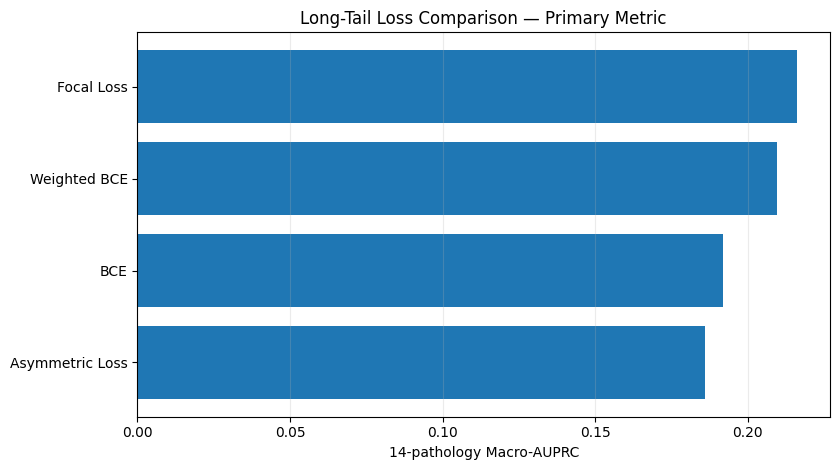

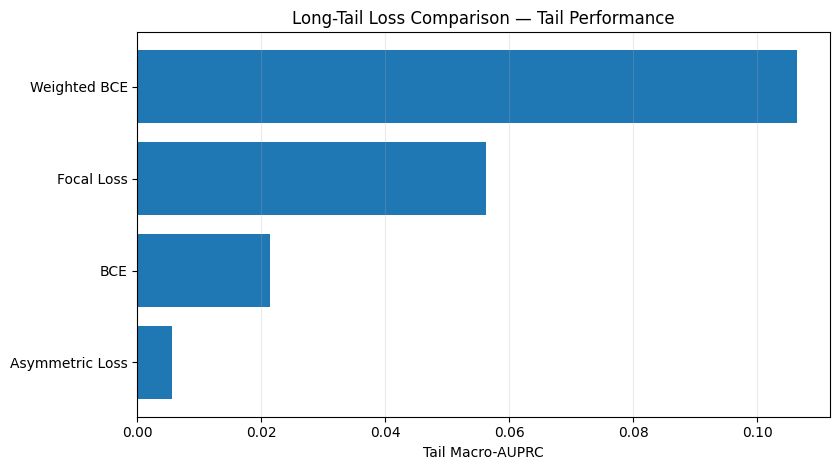

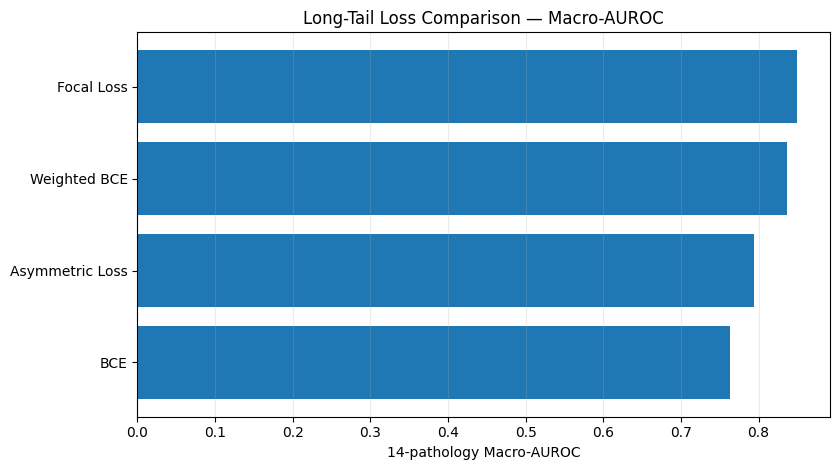

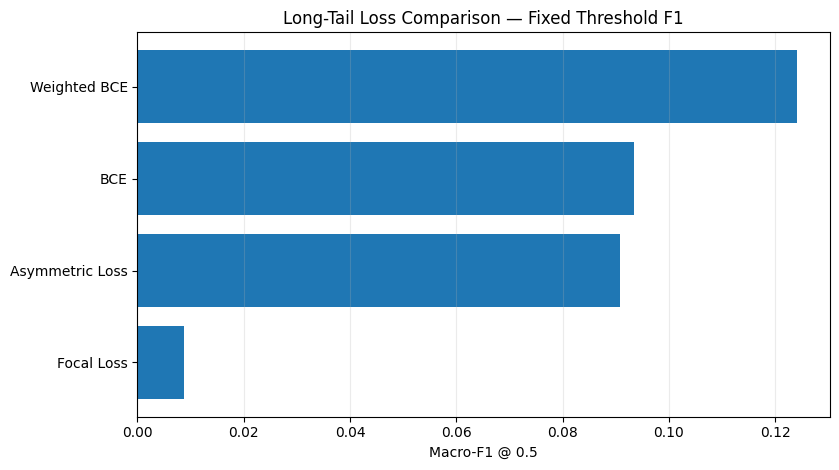

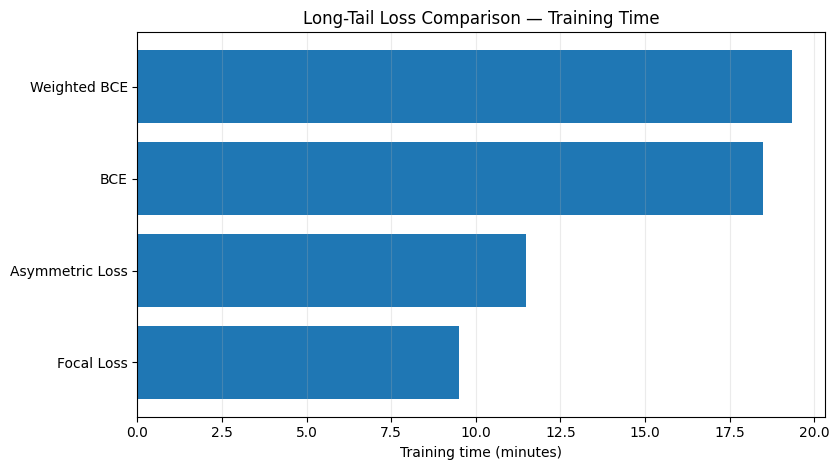

In [8]:
# ============================================================
# 8. Main comparison figures
# ============================================================
def save_bar(metric, xlabel, title, filename):
    plot_df = comparison.sort_values(
        metric,
        ascending=True,
    )

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.barh(
        plot_df["loss_name"],
        plot_df[metric],
    )
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / filename,
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

save_bar(
    "macro_AUPRC_14",
    "14-pathology Macro-AUPRC",
    "Long-Tail Loss Comparison — Primary Metric",
    "loss_macro_auprc.png",
)

save_bar(
    "tail_macro_AUPRC",
    "Tail Macro-AUPRC",
    "Long-Tail Loss Comparison — Tail Performance",
    "loss_tail_auprc.png",
)

save_bar(
    "macro_AUROC_14",
    "14-pathology Macro-AUROC",
    "Long-Tail Loss Comparison — Macro-AUROC",
    "loss_macro_auroc.png",
)

save_bar(
    "macro_F1_at_0.5",
    "Macro-F1 @ 0.5",
    "Long-Tail Loss Comparison — Fixed Threshold F1",
    "loss_macro_f1_fixed_05.png",
)

save_bar(
    "training_minutes",
    "Training time (minutes)",
    "Long-Tail Loss Comparison — Training Time",
    "loss_training_time.png",
)


,loss_name,head_macro_AUPRC,middle_macro_AUPRC,tail_macro_AUPRC
0,Focal Loss,0.212691,0.347567,0.056256
1,Weighted BCE,0.200695,0.301391,0.106451
2,BCE,0.180373,0.339469,0.021314
3,Asymmetric Loss,0.198328,0.318004,0.005593


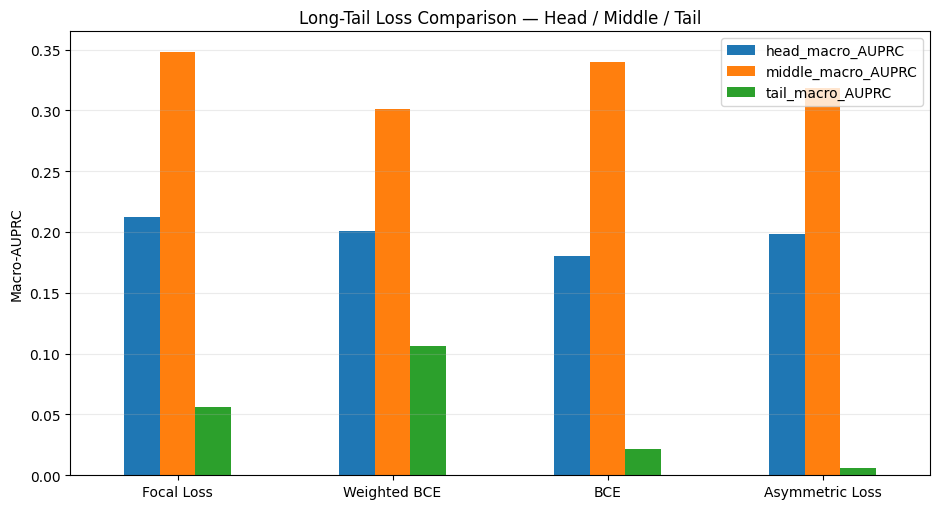

In [9]:
# ============================================================
# 9. Head / Middle / Tail figure
# ============================================================
hmt_df = comparison[
    [
        "loss_name",
        "head_macro_AUPRC",
        "middle_macro_AUPRC",
        "tail_macro_AUPRC",
    ]
].copy()

hmt_df.to_csv(
    TABLE_DIR / "loss_head_middle_tail_comparison.csv",
    index=False,
)

display(hmt_df)

plot_df = hmt_df.set_index("loss_name")

fig, ax = plt.subplots(figsize=(9.5, 5.2))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Macro-AUPRC")
ax.set_xlabel("")
ax.set_title(
    "Long-Tail Loss Comparison — Head / Middle / Tail"
)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "loss_hmt_group_comparison.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


,label,BCE,Weighted BCE,Focal Loss,Asymmetric Loss
0,Brocho-pneumonia,0.150496,0.179403,0.200850,0.194274
1,Bronchiolitis,0.127729,0.093746,0.114492,0.144473
2,Bronchitis,0.207494,0.237075,0.230006,0.192515
3,CPAM,0.047619,0.062500,0.004587,0.009259
4,Congenital emphysema,0.001321,0.027778,0.015385,0.002083
5,Diagphramatic hernia,0.001835,0.333333,0.200000,0.006897
6,Hyaline membrane disease,0.089794,0.066792,0.100768,0.053788
7,Lung tumor,0.034483,0.002193,0.005051,0.004132
8,Mediastinal tumor,0.002833,0.002066,0.002681,0.002294
9,No finding,0.827930,0.846725,0.855310,0.870180


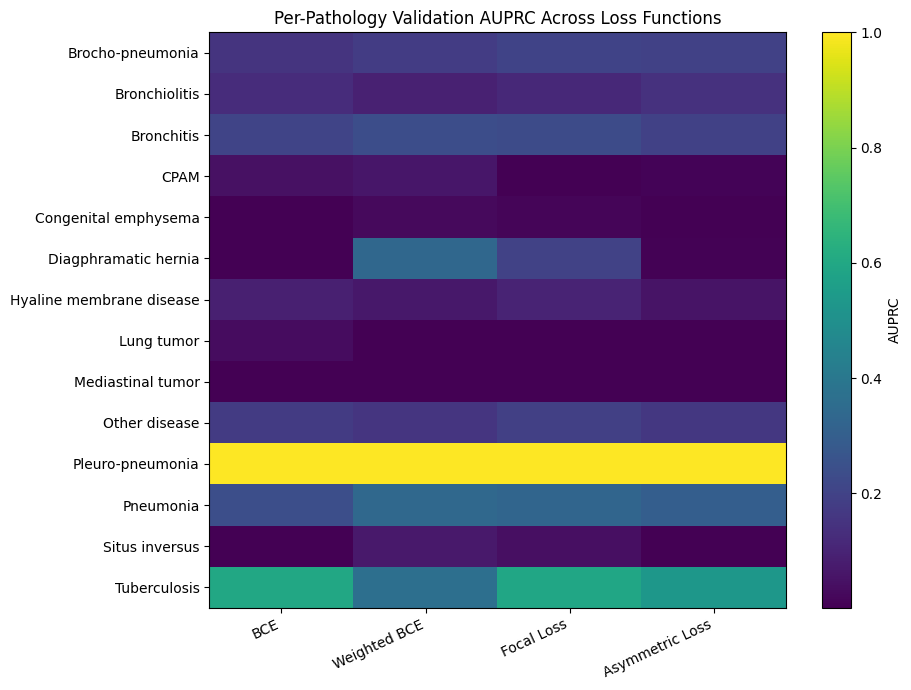

In [10]:
# ============================================================
# 10. Per-class AUPRC comparison
# ============================================================
def standardize_per_class(df, exp_id):
    df = df.copy()

    label_col = None
    for candidate in ["label", "class_name", "pathology"]:
        if candidate in df.columns:
            label_col = candidate
            break

    if label_col is None:
        raise ValueError(
            f"No label column found in per-class table for {exp_id}"
        )

    ap_col = None
    for candidate in ["AUPRC", "auprc", "average_precision"]:
        if candidate in df.columns:
            ap_col = candidate
            break

    if ap_col is None:
        raise ValueError(
            f"No AUPRC column found in per-class table for {exp_id}. "
            f"Columns: {list(df.columns)}"
        )

    out_df = df[[label_col, ap_col]].copy()
    out_df.columns = ["label", EXPECTED_EXPERIMENTS[exp_id]]
    return out_df

merged = None

for exp_id in EXPECTED_EXPERIMENTS:
    tmp = standardize_per_class(
        per_class_tables[exp_id],
        exp_id,
    )

    if merged is None:
        merged = tmp
    else:
        merged = merged.merge(
            tmp,
            on="label",
            how="outer",
        )

display(merged)

merged.to_csv(
    TABLE_DIR / "per_class_AUPRC_all_losses.csv",
    index=False,
)

# Heatmap-like table using matplotlib only.
plot_labels = [
    x for x in merged["label"].tolist()
    if x != "No finding"
]

plot_data = (
    merged
    .set_index("label")
    .loc[plot_labels]
)

fig, ax = plt.subplots(figsize=(9.5, 7))
im = ax.imshow(
    plot_data.values,
    aspect="auto",
)

ax.set_xticks(
    range(len(plot_data.columns))
)
ax.set_xticklabels(
    plot_data.columns,
    rotation=25,
    ha="right",
)

ax.set_yticks(
    range(len(plot_data.index))
)
ax.set_yticklabels(
    plot_data.index,
)

ax.set_title(
    "Per-Pathology Validation AUPRC Across Loss Functions"
)

fig.colorbar(
    im,
    ax=ax,
    label="AUPRC",
)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "per_class_auprc_heatmap.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


In [11]:
# ============================================================
# 11. Research interpretation
# ============================================================
winner = comparison.sort_values(
    "macro_AUPRC_14",
    ascending=False,
).iloc[0]

runner_up = comparison.sort_values(
    "macro_AUPRC_14",
    ascending=False,
).iloc[1]

best_tail = comparison.sort_values(
    "tail_macro_AUPRC",
    ascending=False,
).iloc[0]

best_auroc = comparison.sort_values(
    "macro_AUROC_14",
    ascending=False,
).iloc[0]

summary_lines = [
    "Pedi-CGAM Lite — Stage 07 Long-Tail Loss Comparison",
    "=" * 72,
    "",
    "CONTROLLED SETUP",
    "- Frozen backbone: ResNet50",
    "- Resolution: 320x320",
    "- Same Stage 02 train/validation split",
    "- AdamW, LR 1e-4, weight decay 1e-4",
    "- Batch size 8",
    "- Seed 42",
    "- Calibration split unused",
    "- Official test sealed",
    "",
    "PRIMARY RESULT",
    f"- Selected loss: {winner['loss_name']}",
    (
        f"- 14-pathology Macro-AUPRC: "
        f"{winner['macro_AUPRC_14']:.6f}"
    ),
    (
        f"- Runner-up: {runner_up['loss_name']} "
        f"({runner_up['macro_AUPRC_14']:.6f})"
    ),
    "",
    "SECONDARY EVIDENCE",
    (
        f"- Best Tail Macro-AUPRC: "
        f"{best_tail['loss_name']} "
        f"({best_tail['tail_macro_AUPRC']:.6f})"
    ),
    (
        f"- Best Macro-AUROC: "
        f"{best_auroc['loss_name']} "
        f"({best_auroc['macro_AUROC_14']:.6f})"
    ),
    "",
    "INTERPRETATION",
    (
        "- The loss is frozen according to the pre-declared "
        "primary metric rather than post-hoc preference."
    ),
    (
        "- Tail AUPRC remains important but is highly unstable "
        "for ultra-rare validation classes with very few positives."
    ),
    (
        "- The next scientific step is to keep the selected "
        "backbone/loss fixed and introduce finding supervision."
    ),
    "",
    "NEXT STAGES",
    "- Disease-only frozen final baseline",
    "- Disease + finding multitask supervision",
    "- Box-guided lesion attention",
    "- Pedi-CGAM Lite confidence-guided fusion",
    "- Calibration",
    "- Selective prediction / abstention",
    "",
    "The official test remains sealed.",
]

summary_text = "\n".join(summary_lines)

print(summary_text)

(
    OUTPUT_DIR / "README_STAGE07_RESULTS.txt"
).write_text(summary_text)


Pedi-CGAM Lite — Stage 07 Long-Tail Loss Comparison

CONTROLLED SETUP
- Frozen backbone: ResNet50
- Resolution: 320x320
- Same Stage 02 train/validation split
- AdamW, LR 1e-4, weight decay 1e-4
- Batch size 8
- Seed 42
- Calibration split unused
- Official test sealed

PRIMARY RESULT
- Selected loss: Focal Loss
- 14-pathology Macro-AUPRC: 0.216165
- Runner-up: Weighted BCE (0.209731)

SECONDARY EVIDENCE
- Best Tail Macro-AUPRC: Weighted BCE (0.106451)
- Best Macro-AUROC: Focal Loss (0.849518)

INTERPRETATION
- The loss is frozen according to the pre-declared primary metric rather than post-hoc preference.
- Tail AUPRC remains important but is highly unstable for ultra-rare validation classes with very few positives.
- The next scientific step is to keep the selected backbone/loss fixed and introduce finding supervision.

NEXT STAGES
- Disease-only frozen final baseline
- Disease + finding multitask supervision
- Box-guided lesion attention
- Pedi-CGAM Lite confidence-guided fusion
- C

1154

In [12]:
# ============================================================
# 12. Final integrity gate
# ============================================================
checks = pd.DataFrame([
    {
        "check": "All 4 loss experiments discovered",
        "passed": len(discovered) == 4,
    },
    {
        "check": "All common protocol checks passed",
        "passed":
            verification_df["all_common_checks_pass"].all(),
    },
    {
        "check": "Primary metrics finite",
        "passed":
            np.isfinite(comparison["macro_AUPRC_14"]).all(),
    },
    {
        "check": "Tail metrics finite",
        "passed":
            np.isfinite(comparison["tail_macro_AUPRC"]).all(),
    },
    {
        "check": "Exactly one final loss frozen",
        "passed":
            isinstance(FINAL_LOSS, str)
            and len(FINAL_LOSS) > 0,
    },
    {
        "check": "Calibration remained unused",
        "passed": all(
            info["config"].get("calibration_used") is False
            for info in discovered.values()
        ),
    },
    {
        "check": "Official test remained sealed",
        "passed": all(
            info["config"].get("official_test_used") is False
            for info in discovered.values()
        ),
    },
])

checks["status"] = checks["passed"].map(
    {True: "PASS", False: "REVIEW"}
)

display(checks)

checks.to_csv(
    OUTPUT_DIR / "stage07_final_status.csv",
    index=False,
)

FINAL_STATUS = (
    "PASS"
    if checks["passed"].all()
    else "REVIEW"
)

print("\n" + "=" * 72)
print("STAGE 07 FINAL STATUS:", FINAL_STATUS)

if FINAL_STATUS == "PASS":
    print("✅ LONG-TAIL LOSS COMPARISON COMPLETE")
    print("🔒 FINAL LOSS FROZEN:", FINAL_LOSS)
    print("🔒 BACKBONE REMAINS: ResNet50 @ 320x320")
else:
    print("⚠️ REVIEW BEFORE STARTING MULTITASK EXPERIMENTS")

print("=" * 72)


,check,passed,status
0,All 4 loss experiments discovered,True,PASS
1,All common protocol checks passed,True,PASS
2,Primary metrics finite,True,PASS
3,Tail metrics finite,True,PASS
4,Exactly one final loss frozen,True,PASS
5,Calibration remained unused,True,PASS
6,Official test remained sealed,True,PASS



STAGE 07 FINAL STATUS: PASS
✅ LONG-TAIL LOSS COMPARISON COMPLETE
🔒 FINAL LOSS FROZEN: Focal Loss
🔒 BACKBONE REMAINS: ResNet50 @ 320x320


In [13]:
# ============================================================
# 13. ZIP the ENTIRE Stage 07 output folder into ONE file
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/"
    "PediCGAM_Stage07_LongTail_Loss_Comparison_All_Outputs.zip"
)

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

source_files = sorted(
    p for p in OUTPUT_DIR.rglob("*")
    if p.is_file()
)

if not source_files:
    raise RuntimeError(
        "No Stage 07 outputs found to package."
    )

# Restricted-data guard.
for p in source_files:
    if p.suffix.lower() in {".dcm", ".dicom"}:
        raise RuntimeError(
            f"STOP: DICOM detected in Stage 07 output: {p}"
        )

with zipfile.ZipFile(
    ZIP_FILE,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        rel = p.relative_to(OUTPUT_DIR)
        zf.write(
            p,
            arcname=str(
                Path("stage07_longtail_loss_comparison")
                / rel
            ),
        )

with zipfile.ZipFile(ZIP_FILE, "r") as zf:
    bad = zf.testzip()
    archive_names = zf.namelist()

if bad is not None:
    raise RuntimeError(
        f"ZIP integrity failure: {bad}"
    )

expected_names = {
    str(
        Path("stage07_longtail_loss_comparison")
        / p.relative_to(OUTPUT_DIR)
    )
    for p in source_files
}

missing = expected_names - set(archive_names)

if missing:
    raise RuntimeError(
        "ZIP missing Stage 07 outputs: "
        + ", ".join(sorted(missing)[:20])
    )

print("✅ STAGE 07 COMPLETE OUTPUT ZIP CREATED")
print("File:", ZIP_FILE)
print("Archived files:", len(source_files))
print(
    f"ZIP size: "
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB"
)
print("ZIP integrity: PASS")
print("DICOM files included: NO")
print("\nDownload this ONE ZIP from Kaggle Output.")


✅ STAGE 07 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/PediCGAM_Stage07_LongTail_Loss_Comparison_All_Outputs.zip
Archived files: 16
ZIP size: 0.35 MB
ZIP integrity: PASS
DICOM files included: NO

Download this ONE ZIP from Kaggle Output.


## After Stage 07 passes

Freeze both:

- **Backbone:** ResNet50 @ 320×320
- **Loss:** automatically selected by the pre-declared primary metric

Then stop loss searching.

The next experiment family should study **richer radiological supervision**, not more generic loss functions:

- `08_Disease_Only_Final_Baseline.ipynb`
- `09_Disease_and_Finding_Multitask.ipynb`
- `10_Box_Guided_Attention.ipynb`
- `11_Pedi_CGAM_Lite.ipynb`

The calibration split and official test must remain untouched until their designated stages.
